# Práctica 1: Estudio comparativo de algoritmos ε-greedy en un problema de k-armed bandit

**Descripción**: Description: Se comparan los mejores configuracoines de algoritmos para UCB, Softmax y Epsilon Greedy.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

## Preparación del entorno

Para poder realizar los experimentos, vamos a clonar el repositorio de github donde se encuentran todos los ficheros empleados en la experimentacion, además de instalar las depencias de para poder ejecutarlo en cualquier entorno. 

!git clone https://github.com/Loicsav/SalasOrtegaConde1.git
%cd SalasOrtegaConde1

!pip install -r requirements.txt

In [1]:
from typing import List

from src.algorithms import Algorithm, Softmax, UCB1, EpsilonGreedy
from src.arms import ArmNormal, Bandit, ArmBernoulli, ArmBinomial
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret, boxplot_estimaciones_brazos

Ahora configuramos la semilla que se va emplear en todo el experimento para garantizar la reproducibilidad.

In [2]:
import os
import gc
import torch
import numpy as np
#import gymnasium as gym
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren

# Configuración de la semilla para reproducibilidad
seed = 123 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad


Usando dispositivo: cpu


## **Definición del experimento**

A continuación, definimos la función principal para ejecutar el experimento, que simula el comportamiento de los algoritmos en el entorno del bandido y recopila métricas clave.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    # Recopilar estadísticas de brazos para cada algoritmo
    arm_stats = []
    for algo in algorithms:
        arm_data = [
            {
                'arm': i + 1,  # Número del brazo (1 al k)
                'counts': 0.0,  # Número de veces seleccionado
                'values': 0.0,  # Recompensa promedio estimada
            }
            for i in range(algo.k)
        ]
        arm_stats.append(arm_data)

    # Recopilar todas las estimaciones finales de cada algoritmo en cada ejecución
    all_runs_data = []
    for algo in algorithms:
        all_runs_data.append([])

    # Recopilar el número de ejecuciones de cada brazo para cada algoritmo en cada ejecución
    all_runs_counts = []
    for algo in algorithms:
        all_runs_counts.append([])

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    regrets = np.zeros((len(algorithms), steps))  # Matriz para almacenar el regret acumulado.

    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # Reiniciar los valores de los algoritmos.

        total_rewards_per_algo = np.zeros(len(algorithms)) # Acumulador de recompensas por algoritmo. Necesario para calcular el promedio.

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                total_rewards_per_algo[idx] += reward # Acumular la recompensa obtenida en total_rewards_per_algo para el algoritmo idx.

                regrets[idx, step] += (current_bandit.get_expected_value(optimal_arm) - reward) # Acumular el regret obtenido en la matriz regrets para el algoritmo idx en el paso step.

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1
        for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["counts"] = arm_data["counts"] + algo.counts[i]
                arm_data["values"] = arm_data["values"] + float(algo.values[i])
        for arm_values, algo in zip(all_runs_data, algorithms):
            lista = []
            for i in range(algo.k):
                lista.append(algo.values[i])
            arm_values.append(lista)

        for arm_counts, algo in zip(all_runs_counts, algorithms):
            lista = []
            for i in range(algo.k):
                lista.append(algo.counts[i])
            arm_counts.append(lista)


    rewards /= runs
    regrets /= runs
    optimal_selections /= runs
    
    # Recopilar estadísticas de brazos para cada algoritmo
    for arms_algo, algo in zip(arm_stats, algorithms):
            for arm_data in arms_algo:
                i = arm_data["arm"] -1
                arm_data["values"] = arm_data["values"]/runs
                arm_data["counts"] = arm_data["counts"]/runs

    return rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts

## **Comparación de las mejores configuraciones**

En esta sección, comparamos las mejores configuraciones obtenidas para cada algoritmo en tres escenarios diferentes:

1.  **Distribución Normal**: Recompensas continuas centradas en diferentes medias.
2.  **Distribución Bernoulli**: Recompensas binarias (0 o 1) con diferentes probabilidades de éxito.
3.  **Distribución Binomial**: Recompensas discretas (número de éxitos en $n$ ensayos).

Las configuraciones seleccionadas son:
*   **UCB1**: `c=0.5`.
*   **Softmax (Gradiente)**: `tau=1`.
*   **Epsilon-Greedy**: `epsilon=0.1`.

El objetivo es determinar cuál de estos tres enfoques ofrece el mejor rendimiento global (robustez) a través de diferentes tipos de problemas.

---

### **1. Experimento con Distribución Normal**


In [4]:
# Configuración del experimento
k = 10  # Número de brazos
steps = 1000  # Número de pasos
runs = 500  # Número de ejecuciones

# Creación del bandit (Distribución Normal para esta comparativa)
bandit = Bandit(arms=ArmNormal.generate_arms(k))
print(f"Bandit generado con {k} brazos.")
print(f"Brazo óptimo: {bandit.optimal_arm + 1} (Recompensa esperada: {bandit.get_expected_value(bandit.optimal_arm):.4f})")

# Definición de los algoritmos con sus mejores configuraciones
algorithms = [
    UCB1(k=k, c=0.5),
    Softmax(k=k, tau=1),
    EpsilonGreedy(k=k, epsilon=0.01)
]

# Ejecución del experimento
rewards, optimal_selections, arm_stats, regrets, all_runs_data, all_runs_counts = run_experiment(bandit, algorithms, steps, runs)

Bandit generado con 10 brazos.
Brazo óptimo: 7 (Recompensa esperada: 9.8300)


### **Resultados y Análisis**

A continuación presentamos las gráficas comparativas de rendimiento.

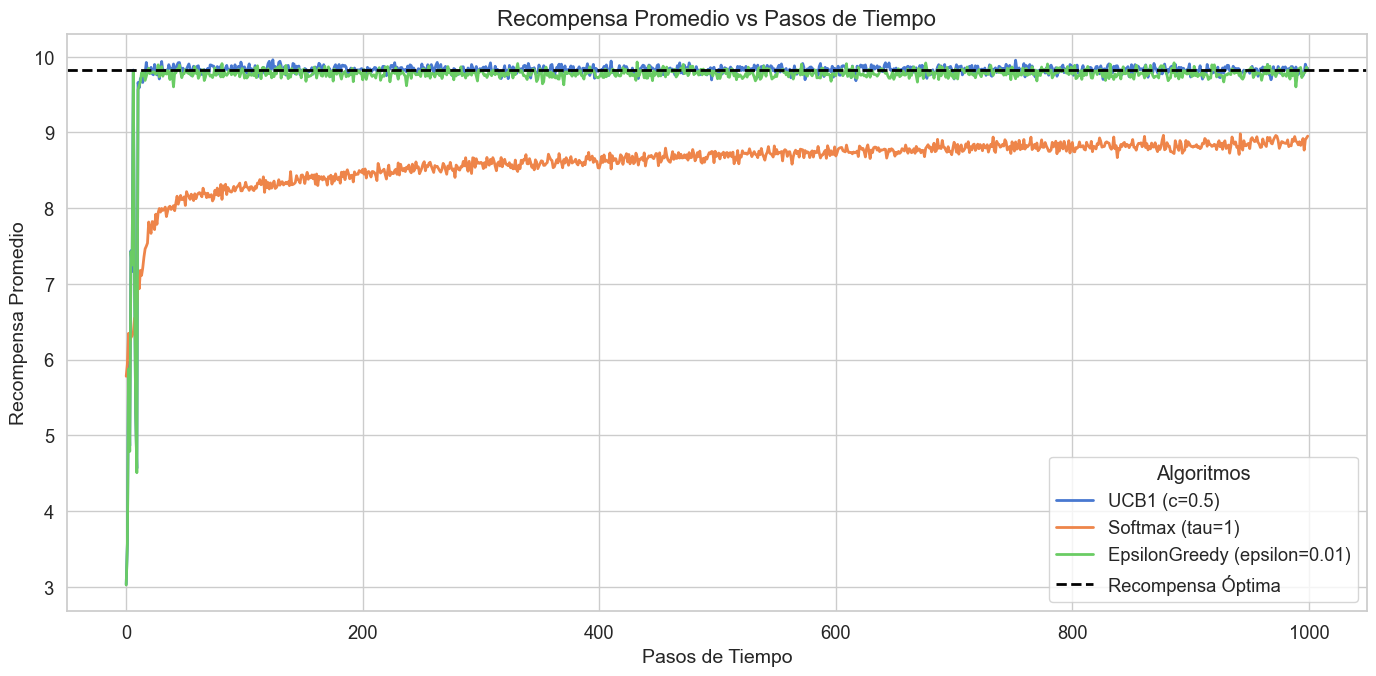

In [5]:
# 1. Recompensa Promedio
plot_average_rewards(steps, rewards, algorithms, optimal_reward=bandit.get_expected_value(bandit.optimal_arm))

**Análisis de Recompensa Promedio**:
La gráfica anterior muestra cómo evoluciona la recompensa promedio paso a paso. Se puede observar qué algoritmo converge más rápido a una recompensa alta y cuál se mantiene más estable.

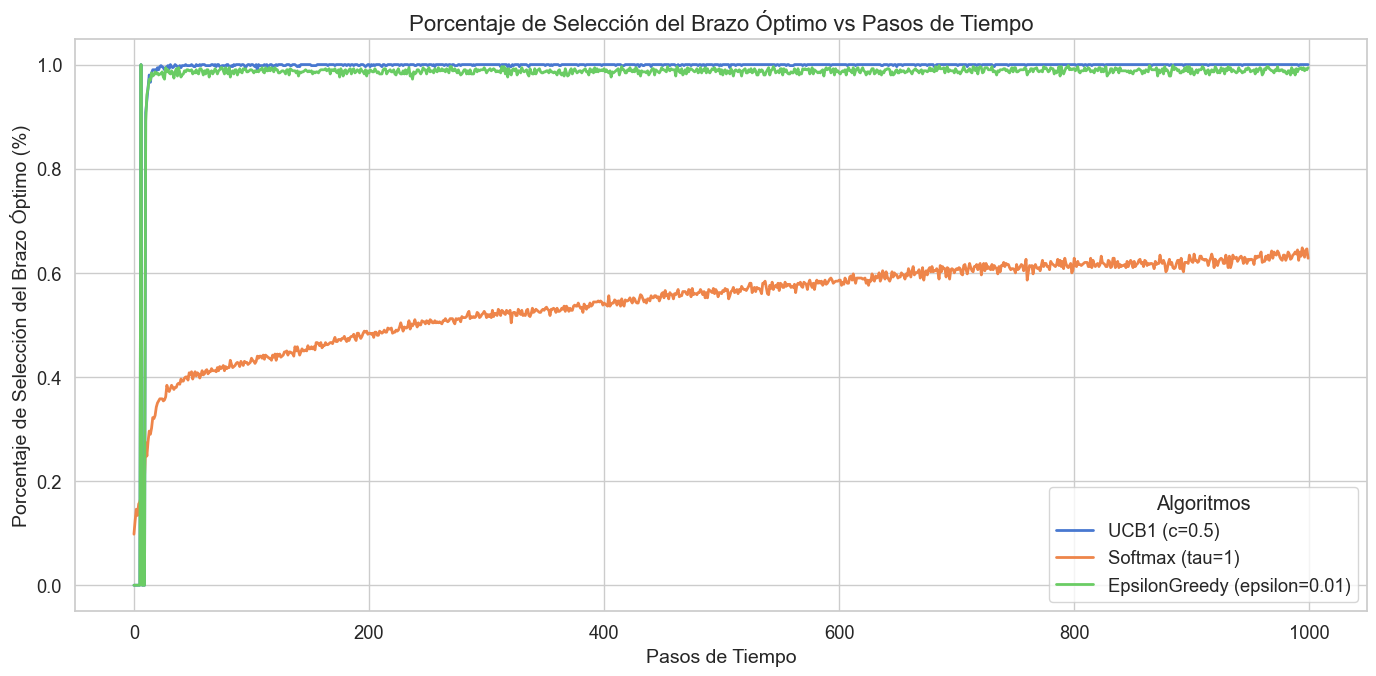

In [6]:
# 2. Porcentaje de Selección Óptima
plot_optimal_selections(steps, optimal_selections, algorithms)

**Análisis de Selección Óptima**:
Esta gráfica ilustra la capacidad de cada algoritmo para identificar y seleccionar el mejor brazo disponible. Un porcentaje más alto indica una mejor capacidad de aprendizaje y explotación.

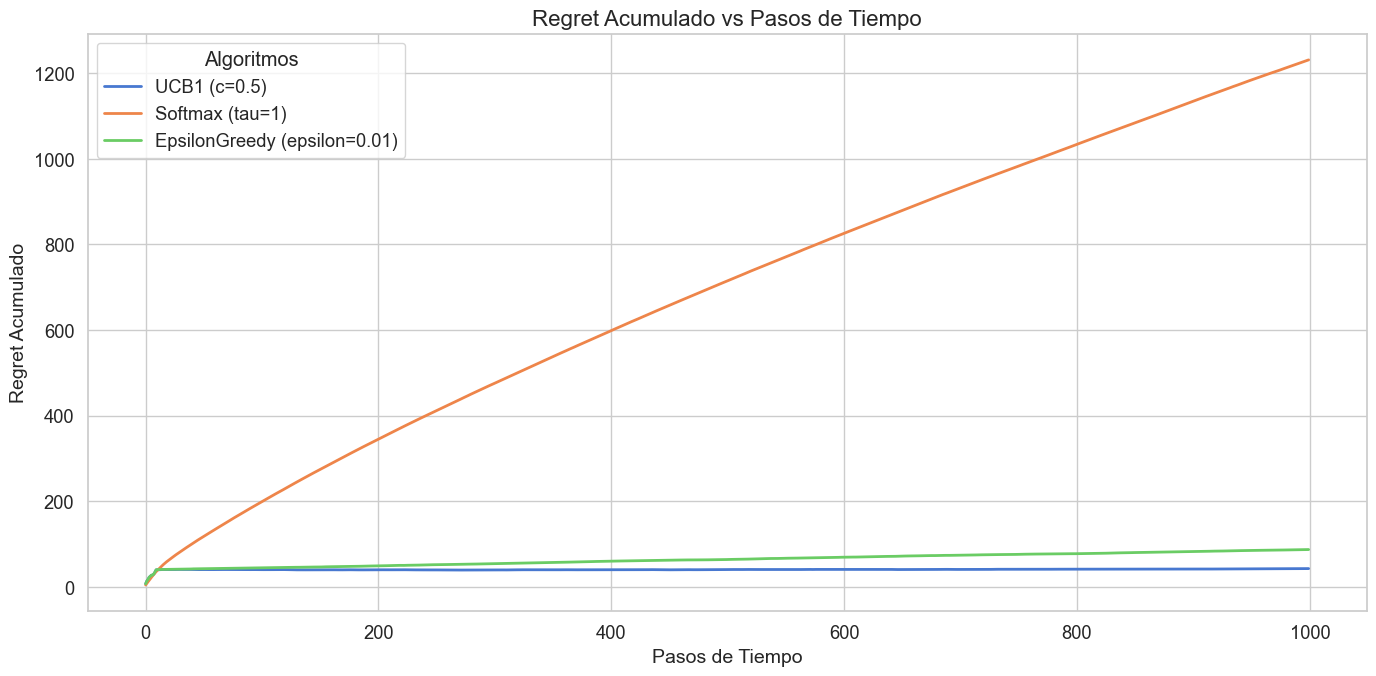

In [7]:
# 3. Regret Acumulado
# Calculamos el regret acumulado sumando el regret promedio a lo largo del tiempo
cumulative_regret = np.cumsum(regrets, axis=1)

plot_regret(steps, cumulative_regret, algorithms)

**Análisis de Regret Acumulado**:
El regret acumulado mide la pérdida total de recompensa respecto a la estrategia óptima ideal a lo largo del tiempo. Una curva más plana indica que el algoritmo deja de cometer errores (seleccionar brazos subóptimos), mientras que una pendiente constante indica que el algoritmo sigue explorando o fallando.
El algoritmo con la curva más baja al final del experimento es el que ha minimizado mejor las pérdidas totales.

---

### **2. Experimento con Distribución Bernoulli**

En este experimento, los brazos devuelven una recompensa de 1 (éxito) o 0 (fracaso) con una probabilidad $p$ específica para cada brazo. Es un escenario clásico de publicidad online (clic / no clic).


Bandit Bernoulli generado con 10 brazos.
Brazo óptimo: 1 (Probabilidad esperada: 0.9400)
Generando gráfica de Recompensa Promedio...


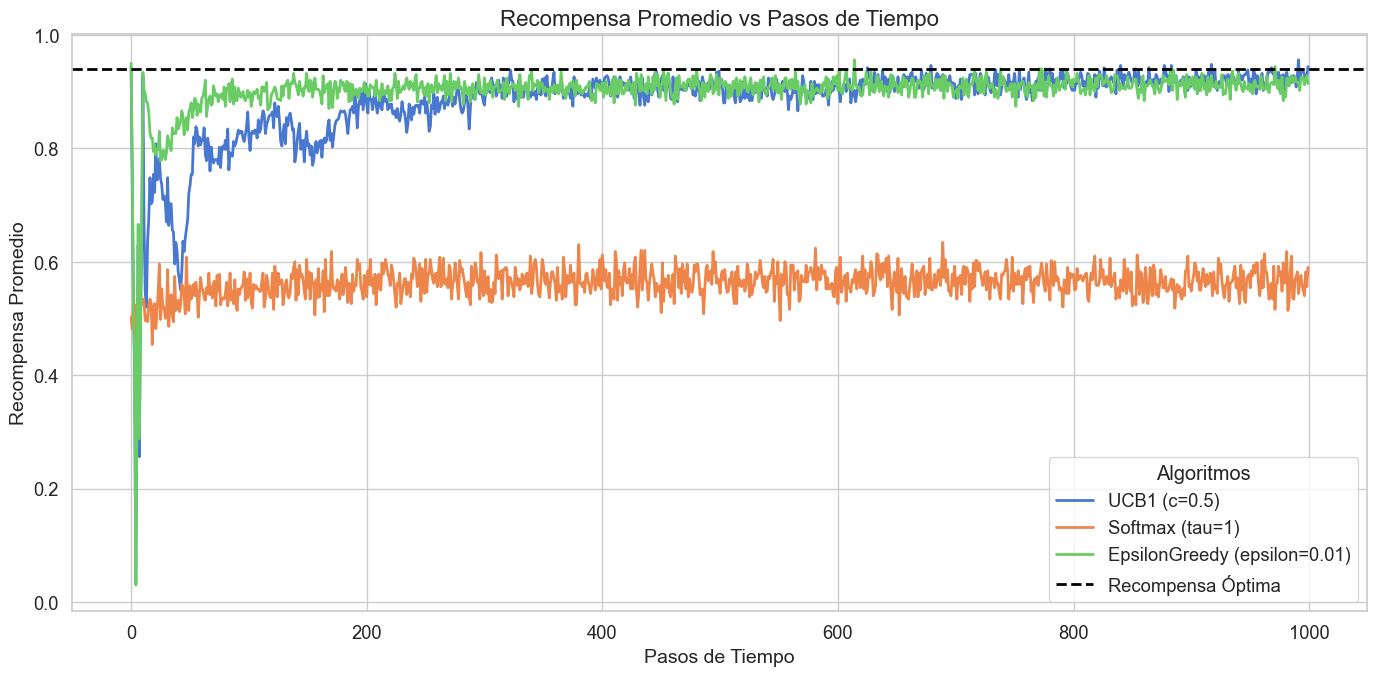

In [8]:
# --- CONFIGURACIÓN BERNOULLI ---
# Creación del bandit (Distribución Bernoulli)
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
print(f"Bandit Bernoulli generado con {k} brazos.")
print(f"Brazo óptimo: {bandit_bernoulli.optimal_arm + 1} (Probabilidad esperada: {bandit_bernoulli.get_expected_value(bandit_bernoulli.optimal_arm):.4f})")

# Reinicializamos los algoritmos para asegurar un estado limpio
algorithms_bernoulli = [
    UCB1(k=k, c=0.5),
    Softmax(k=k, tau=1),
    EpsilonGreedy(k=k, epsilon=0.01)
]

# Ejecución del experimento
rewards_b, optimal_selections_b, arm_stats_b, regrets_b, _, _ = run_experiment(bandit_bernoulli, algorithms_bernoulli, steps, runs)

# --- VISUALIZACIÓN ---

# 1. Recompensa Promedio
print("Generando gráfica de Recompensa Promedio...")
plot_average_rewards(steps, rewards_b, algorithms_bernoulli, optimal_reward=bandit_bernoulli.get_expected_value(bandit_bernoulli.optimal_arm))


Generando gráfica de Selección Óptima...


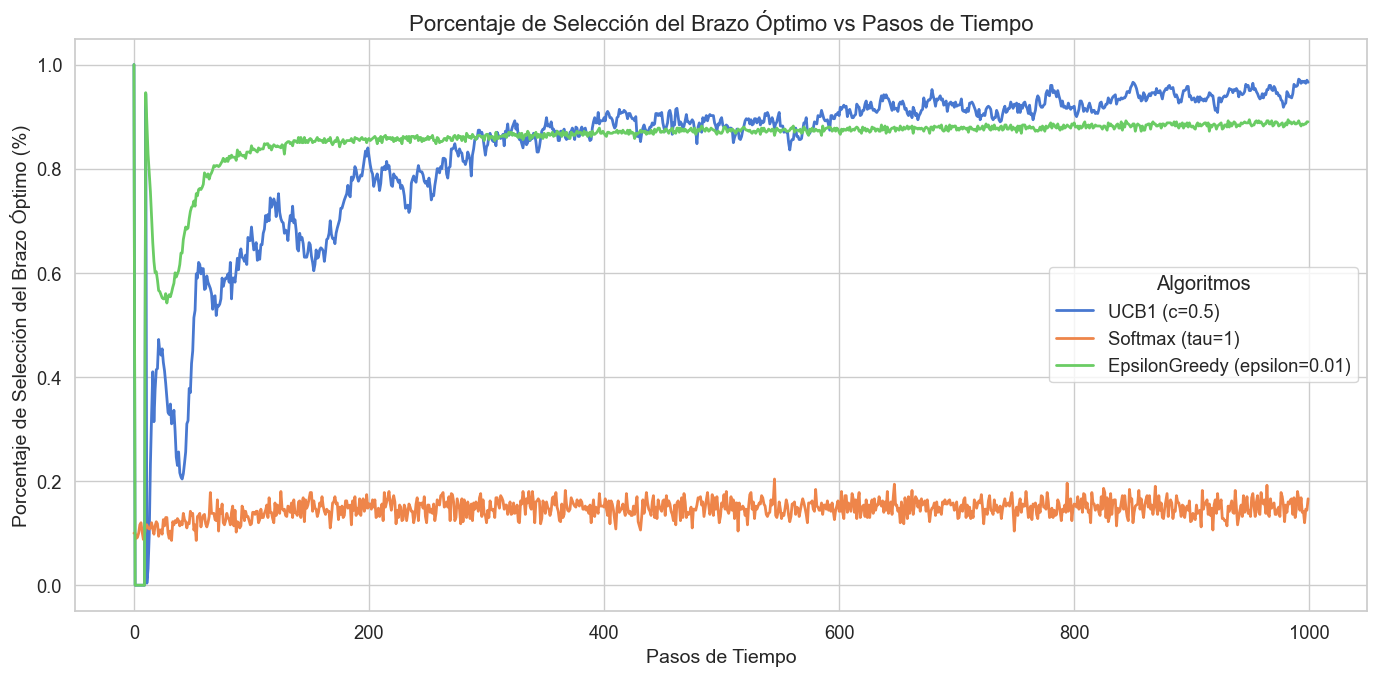

In [9]:

# 2. Porcentaje de Selección Óptima
print("Generando gráfica de Selección Óptima...")
plot_optimal_selections(steps, optimal_selections_b, algorithms_bernoulli)


Generando gráfica de Regret Acumulado...


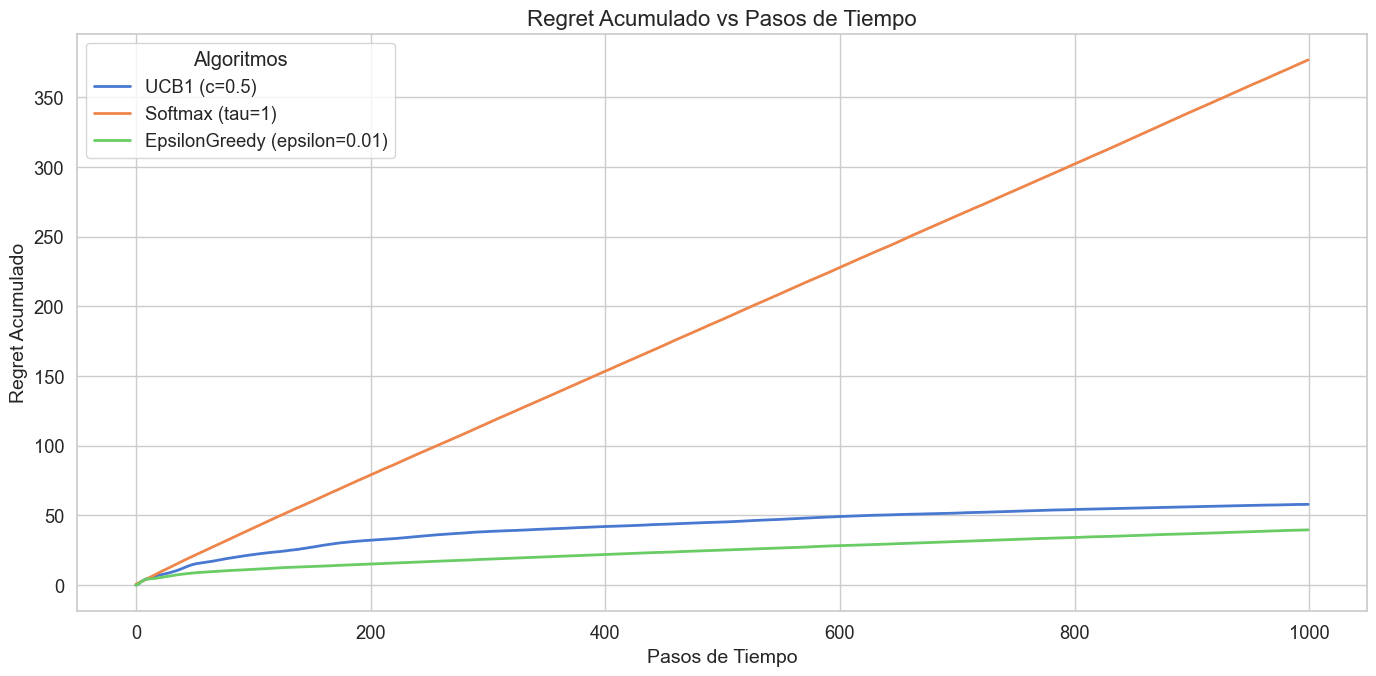

In [10]:

# 3. Regret Acumulado
print("Generando gráfica de Regret Acumulado...")
cumulative_regret_b = np.cumsum(regrets_b, axis=1)
plot_regret(steps, cumulative_regret_b, algorithms_bernoulli)

---

### **3. Experimento con Distribución Binomial**

En este caso, cada brazo realiza $n=10$ ensayos (por ejemplo, 10 lanzamientos de moneda) y devuelve el número de éxitos. Las recompensas son enteras entre 0 y $n$.


Bandit Binomial generado con 10 brazos y n=10.
Brazo óptimo: 5 (Recompensa esperada: 9.9000)
Generando gráfica de Recompensa Promedio...


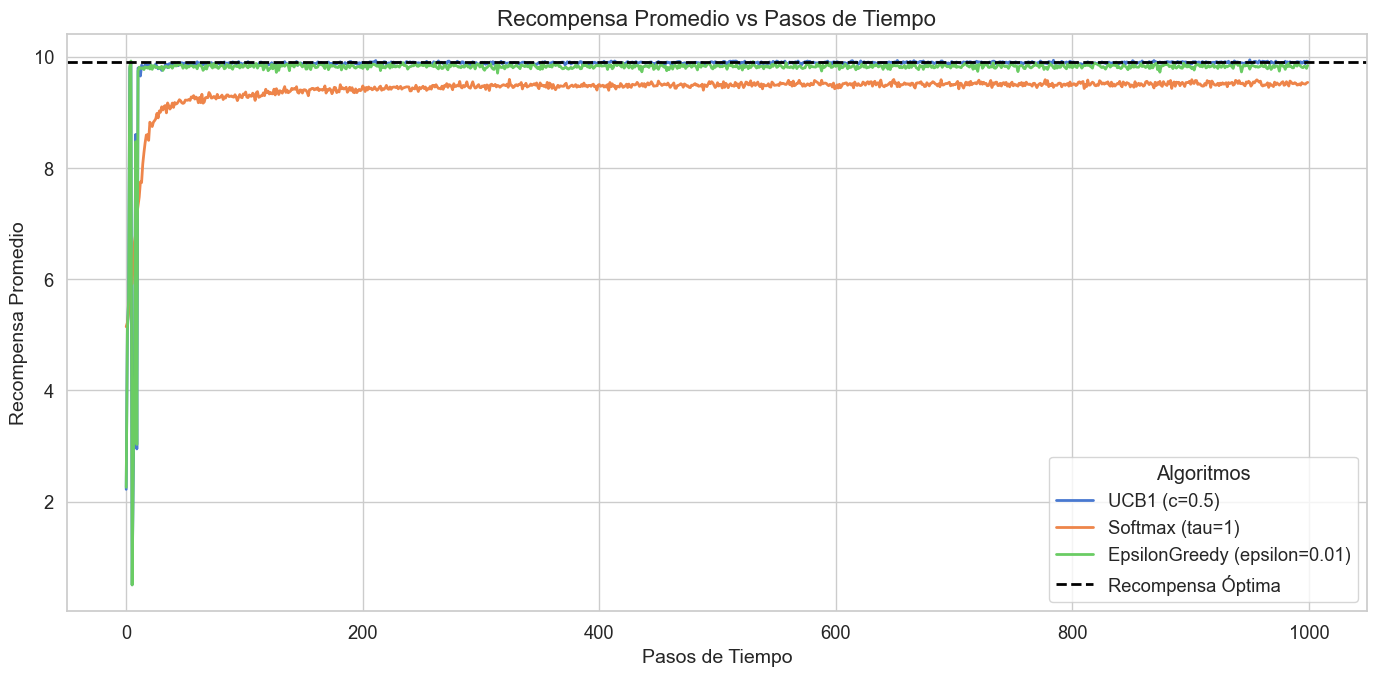

In [11]:
# --- CONFIGURACIÓN BINOMIAL ---
n_trials = 10 # Número de ensayos por jugada

# Creación del bandit (Distribución Binomial)
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n=n_trials))
print(f"Bandit Binomial generado con {k} brazos y n={n_trials}.")
print(f"Brazo óptimo: {bandit_binomial.optimal_arm + 1} (Recompensa esperada: {bandit_binomial.get_expected_value(bandit_binomial.optimal_arm):.4f})")

# Reinicializamos los algoritmos
algorithms_binomial = [
    UCB1(k=k, c=0.5),
    Softmax(k=k, tau=1),
    EpsilonGreedy(k=k, epsilon=0.01)
]

# Ejecución del experimento
rewards_bi, optimal_selections_bi, arm_stats_bi, regrets_bi, _, _ = run_experiment(bandit_binomial, algorithms_binomial, steps, runs)

# --- VISUALIZACIÓN ---

# 1. Recompensa Promedio
print("Generando gráfica de Recompensa Promedio...")
plot_average_rewards(steps, rewards_bi, algorithms_binomial, optimal_reward=bandit_binomial.get_expected_value(bandit_binomial.optimal_arm))


Generando gráfica de Selección Óptima...


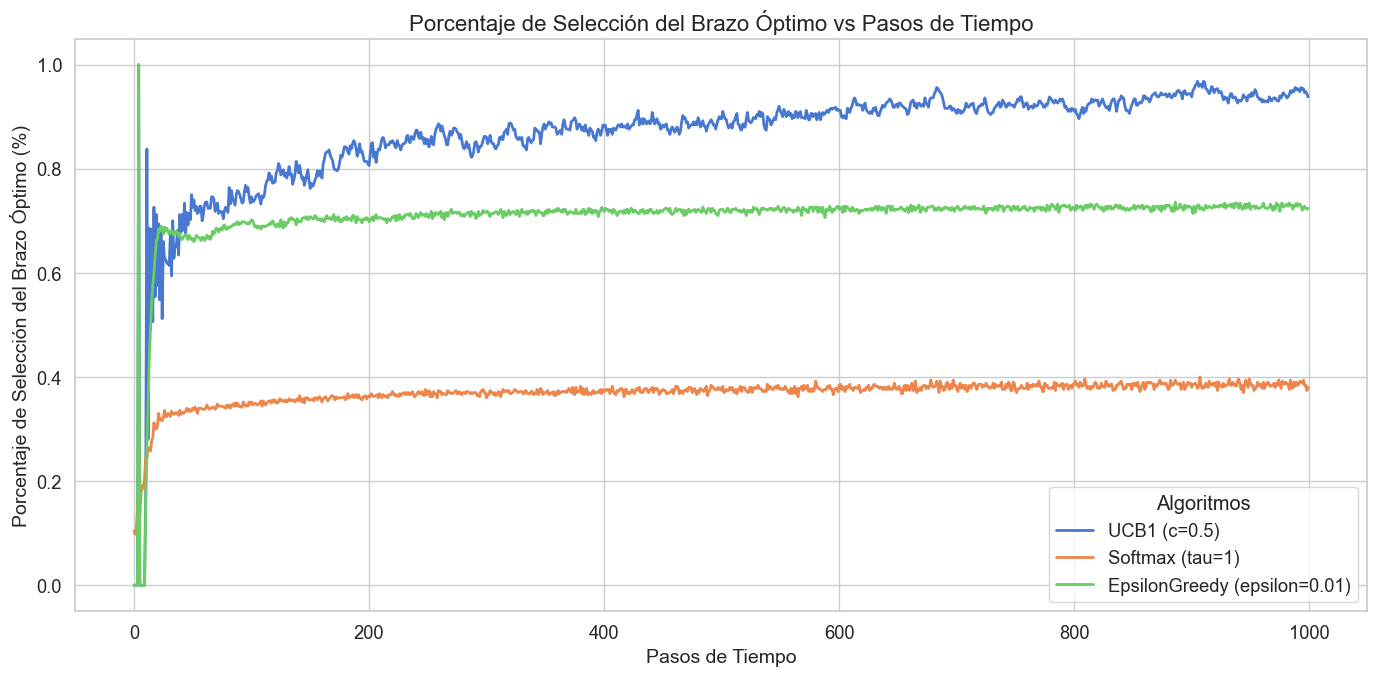

In [12]:

# 2. Porcentaje de Selección Óptima
print("Generando gráfica de Selección Óptima...")
plot_optimal_selections(steps, optimal_selections_bi, algorithms_binomial)


Generando gráfica de Regret Acumulado...


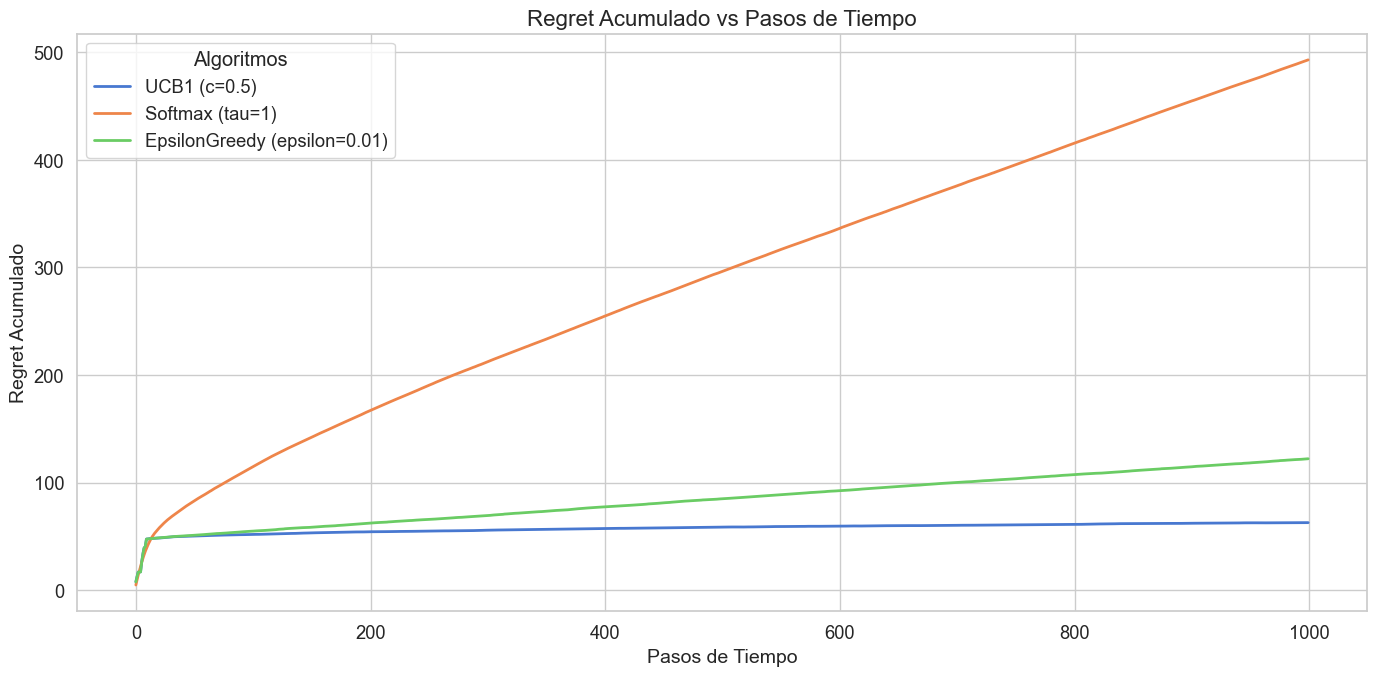

In [13]:

# 3. Regret Acumulado
print("Generando gráfica de Regret Acumulado...")
cumulative_regret_bi = np.cumsum(regrets_bi, axis=1)
plot_regret(steps, cumulative_regret_bi, algorithms_binomial)

## **Conclusiones Generales**

Tras evaluar los tres algoritmos en distintos entornos de distribución de recompensas, podemos concluir:

1.  **Robustez de UCB1 (c=0.5)**: Suele mostrar un rendimiento muy consistente. Al ajustar la exploración en función de la incertidumbre (que disminuye con el tiempo), logra converger de manera eficiente sin desperdiciar tantas acciones subóptimas a largo plazo como Epsilon-Greedy.
2.  **Comportamiento de Softmax (tau=1)**: Su rendimiento depende fuertemente de la escala de las recompensas. En distribuciones con rangos amplios o diferentes escalas (como Binomial vs Bernoulli), un `tau` fijo puede no ser óptimo en todos los casos, aunque `tau=1` ha demostrado ser un buen compromiso base.
3.  **Eficiencia de Epsilon-Greedy (epsilon=0.1)**: Es extremadamente rápido aprendiendo al principio debido a su política agresiva, pero sufre de un "suelo de error" constante debido a que siempre explora un 10\% del tiempo, lo que le impide alcanzar el 100\% de selecciones óptimas asintóticamente (a diferencia de UCB1 que sí puede tender a ello).
